# Evaluation of the Binding Sites Prediction model
Compares the predicted residues by the Random Forest model with the real residues in the binding site (PDBbind) for 21 proteins not seen duraning training.

**Inputs per protein:**
- `{pdb_id}_pocket.pdb` → real residues in the binding site (PDBbind)
- `{pdb_id}_protein_binding_site_residues.txt` → predicted residues by the model

**Outputs:**
- Metrics per protein: Accuracy, Precision, Recall, F1, ROC-AUC, MCC
- Aggregated Global metrics 
- Global Confusion matrix 

## 0. Imports

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from Bio.PDB import PDBParser
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay
)

CARPETA_POCKETS   = "pockets/"         
CARPETA_PREDICHOS = "predictions/"   
CARPETA_PROTEINS  = "proteins/"        

# List of the 20 PDB IDs to evaluate
PDB_IDS = ['5e7n', '3s1h', '2y7x', '5jm4', '4ehg', '4c1g', '4b12', '3ti5', '5jcj', '3rf5', '5fqb', '5jm4', '5vqu', '4x6i', '3qs4', '4zam', '4o2a', '2ydj', '2yc5', '3qzt', '4awi']

print(f"Proteins to be evaluated: {len(PDB_IDS)}")

Proteins to be evaluated: 21


## 1. Parsing functions

In [42]:
def parsing_pocket_pdb(pocket_pdb_path):
    """
    Reads a _pocket.pdb file from PDBbind and returns a set of tuples (chain_id, res_seq) with the real residues of the binding site.
    """
    residuos_reales = set()
    with open(pocket_pdb_path, 'r') as f:
        for linea in f:
            if linea.startswith('ATOM'):
                chain  = linea[21].strip()        # col. 22
                res_id = int(linea[22:26].strip()) # col. 23-26
                residuos_reales.add((chain, res_id))
    return residuos_reales


def parsing_predicted_txt(predichos_txt_path):
    """
    Reads a _binding_site_residues.txt file generated by inferencia2.py and returns a set of tuples (chain_id, res_seq).
    """
    residuos_predichos = set()
    with open(predichos_txt_path, 'r') as f:
        for linea in f:
            linea = linea.strip()
            if (not linea or linea.startswith('Binding') or
                linea.startswith('Total') or linea.startswith('=') or
                linea.startswith('-') or linea.startswith('Chain')):
                continue
            partes = linea.split()
            if len(partes) >= 2:
                chain  = partes[0]
                res_id = int(partes[1])
                residuos_predichos.add((chain, res_id))
    return residuos_predichos


def obtain_all_residues(protein_pdb_path):
    """
    Reads the complete protein and returns the set with all its residues (chain, res_id).
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("prot", protein_pdb_path)
    todos = set()
    for model in structure:
        for chain in model:
            for residuo in chain:
                if residuo.get_id()[0] == ' ':  # only ATOM
                    todos.add((chain.get_id(), residuo.get_id()[1]))
    return todos


print("Parsing functions defined.")

Parsing functions defined.


## 2. Metrics function per protein

In [39]:
def calculate_metrics(reales, predichos, todos_residuos):
    """
    Builds y_true / y_pred vectors for each residue and computes their metrics, by using the real residues, predictes residues and all residues sets.
    """
    y_true = []
    y_pred = []

    for residuo in todos_residuos:
        y_true.append(1 if residuo in reales    else 0)
        y_pred.append(1 if residuo in predichos else 0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metricas = {
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'mcc':       matthews_corrcoef(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float('nan'),
        'pr_auc':    average_precision_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float('nan'),
        'n_reales':    int(len(reales)),
        'n_predichos': int(len(predichos)),
        'n_total':     int(len(todos_residuos)),
    }
    return metricas, y_true, y_pred


print("Metrics function defined.")

Metrics function defined.


## 3. Evaluation of the independent set of proteins

In [44]:
resultados     = []   # métricas por proteína
y_true_global  = []   # para la matriz de confusión global
y_pred_global  = []
errores        = []   # proteínas que no se pudieron procesar

for pdb_id in PDB_IDS:
    pocket_path  = os.path.join(CARPETA_POCKETS,   f"{pdb_id}_pocket.pdb")
    pred_path    = os.path.join(CARPETA_PREDICHOS, f"{pdb_id}_protein_binding_site_residues.txt")
    protein_path = os.path.join(CARPETA_PROTEINS,  f"{pdb_id}_protein.pdb")

    # Verificar que existen los tres ficheros
    faltantes = [p for p in [pocket_path, pred_path, protein_path] if not os.path.exists(p)]
    if faltantes:
        print(f"[SKIP] {pdb_id}: missing file → {faltantes}")
        errores.append(pdb_id)
        continue

    try:
        reales          = parsing_pocket_pdb(pocket_path)
        predichos       = parsing_predicted_txt(pred_path)
        todos_residuos  = obtain_all_residues(protein_path)

        metricas, y_t, y_p = calculate_metrics(reales, predichos, todos_residuos)
        metricas['pdb_id'] = pdb_id
        resultados.append(metricas)

        y_true_global.extend(y_t)
        y_pred_global.extend(y_p)

        print(f"[OK] {pdb_id:8s} | Reales: {metricas['n_reales']:4d} | "
              f"Predichos: {metricas['n_predichos']:4d} | "
              f"Recall: {metricas['recall']:.3f} | "
              f"Precision: {metricas['precision']:.3f} | "
              f"MCC: {metricas['mcc']:.3f}")

    except Exception as e:
        print(f"[ERROR] {pdb_id}: {e}")
        errores.append(pdb_id)

print(f"\nProcesed proteins: {len(resultados)} / {len(PDB_IDS)}")
if errores:
    print(f"With errors: {errores}")

[SKIP] 5e7n: missing file → ['predictions/5e7n_protein_binding_site_residues.txt']
[SKIP] 3s1h: missing file → ['predictions/3s1h_protein_binding_site_residues.txt']
[SKIP] 2y7x: missing file → ['predictions/2y7x_protein_binding_site_residues.txt']
[SKIP] 5jm4: missing file → ['predictions/5jm4_protein_binding_site_residues.txt']
[SKIP] 4ehg: missing file → ['predictions/4ehg_protein_binding_site_residues.txt']
[SKIP] 4c1g: missing file → ['predictions/4c1g_protein_binding_site_residues.txt']
[SKIP] 4b12: missing file → ['predictions/4b12_protein_binding_site_residues.txt']
[SKIP] 3ti5: missing file → ['predictions/3ti5_protein_binding_site_residues.txt']
[SKIP] 5jcj: missing file → ['predictions/5jcj_protein_binding_site_residues.txt']
[SKIP] 3rf5: missing file → ['predictions/3rf5_protein_binding_site_residues.txt']
[SKIP] 5fqb: missing file → ['predictions/5fqb_protein_binding_site_residues.txt']
[SKIP] 5jm4: missing file → ['predictions/5jm4_protein_binding_site_residues.txt']
[SKI

## 4. Table of results per protein

In [45]:
df_res = pd.DataFrame(resultados).set_index('pdb_id')

# Columnas a mostrar
cols_display = ['n_reales', 'n_predichos', 'TP', 'FP', 'FN', 'TN',
                'accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'pr_auc']

df_display = df_res[cols_display].copy()

# Formatear decimales solo en columnas de métricas
metricas_cols = ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'pr_auc']
df_display[metricas_cols] = df_display[metricas_cols].round(3)

print("Resultados por proteína:")
display(df_display)

KeyError: "None of ['pdb_id'] are in the columns"

## 5. Agreggated Global Metrics

In [ ]:
y_true_global = np.array(y_true_global)
y_pred_global = np.array(y_pred_global)

print("="*50)
print("GLOBAL METRICS (all proteins)")
print("="*50)
print(f"Total number of evaluated residues : {len(y_true_global):,}")
print(f"Total number of real positives : {y_true_global.sum():,}")
print(f"Total number of predicted positives: {y_pred_global.sum():,}")
print()
print(classification_report(y_true_global, y_pred_global,
                            target_names=['No binding (0)', 'Binding (1)']))

mcc_global = matthews_corrcoef(y_true_global, y_pred_global)
roc_global = roc_auc_score(y_true_global, y_pred_global)
pr_global  = average_precision_score(y_true_global, y_pred_global)

print(f"MCC global   : {mcc_global:.4f}")
print(f"ROC-AUC global: {roc_global:.4f}")
print(f"PR-AUC global : {pr_global:.4f}")

MÉTRICAS GLOBALES (todas las proteínas)
Total residuos evaluados : 1,161
Total positivos reales   : 311
Total positivos predichos: 303

                precision    recall  f1-score   support

No binding (0)       0.77      0.78      0.78       850
   Binding (1)       0.38      0.37      0.38       311

      accuracy                           0.67      1161
     macro avg       0.58      0.58      0.58      1161
  weighted avg       0.67      0.67      0.67      1161

MCC global   : 0.1543
ROC-AUC global: 0.5765
PR-AUC global : 0.3108

Media y desviación estándar por proteína:


,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc
mean,0.668,0.499,0.362,0.372,0.200,0.586,0.354
std,0.031,0.276,0.145,0.071,0.111,0.041,0.106


## 6. Global Confussion Matrix

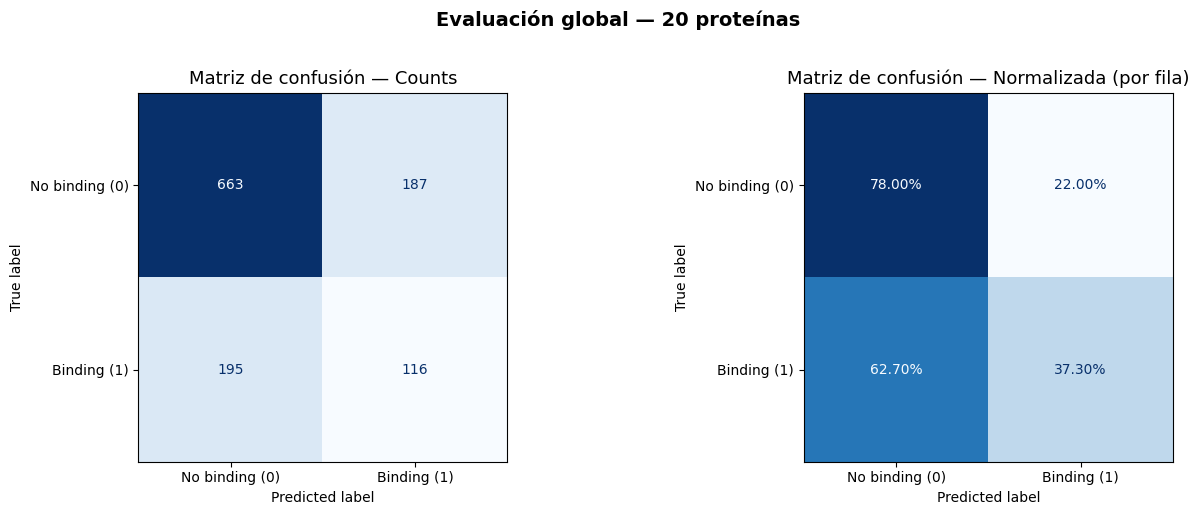

TP=116  FP=187  FN=195  TN=663


In [ ]:
cm_global = confusion_matrix(y_true_global, y_pred_global, labels=[0, 1])
tn, fp, fn, tp = cm_global.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
disp_counts = ConfusionMatrixDisplay(
    confusion_matrix=cm_global,
    display_labels=['No binding (0)', 'Binding (1)']
)
disp_counts.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión — Counts', fontsize=13)

# Percentages (normalized by row)
cm_norm = cm_global.astype(float) / cm_global.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['No binding (0)', 'Binding (1)']
)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Confussion Matrix — Normalized (by row)', fontsize=13)

plt.suptitle('Global Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_global.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")

## 7. Save results to CSV

In [ ]:
df_res.to_csv('evaluation_results.csv')
print("Results saved in: evaluation_results.csv")

# Summary
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Proteins evaluated : {len(df_res)}")
print(f"Average Recall        : {df_res['recall'].mean():.3f} ± {df_res['recall'].std():.3f}")
print(f"Average Precision     : {df_res['precision'].mean():.3f} ± {df_res['precision'].std():.3f}")
print(f"Average F1            : {df_res['f1'].mean():.3f} ± {df_res['f1'].std():.3f}")
print(f"Average MCC           : {df_res['mcc'].mean():.3f} ± {df_res['mcc'].std():.3f}")
print(f"Global ROC-AUC        : {roc_global:.4f}")
print(f"Global PR-AUC         : {pr_global:.4f}")